<a href="https://colab.research.google.com/github/GabrielStaudt/An-lise-Explorat-ria-de-Dados-EDA-/blob/main/analise_exploratoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()
base = pd.read_csv('PimaIndiansDiabetes.csv', sep=';')

Saving PimaIndiansDiabetes.csv to PimaIndiansDiabetes (5).csv


In [ ]:
import pandas as pd

def executar_ingestao(caminho_ficheiro):
    print("--- PROCESSO 1: INGESTÃO E COMPREENSÃO ---")

    df = pd.read_csv(caminho_ficheiro, sep=',')

    print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")
    print("\nInformações das variáveis:")
    df.info()

    print("\nEstatísticas descritivas (dados brutos):")
    print(df.describe())

    return df

if __name__ == "__main__":
    df_bruto = executar_ingestao('PimaIndiansDiabetes.csv')

--- PROCESSO 1: INGESTÃO E COMPREENSÃO ---
Dimensões do dataset: 768 linhas e 9 colunas.

Informações das variáveis:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pregnant  768 non-null    int64  
 1   glucose   768 non-null    int64  
 2   pressure  768 non-null    int64  
 3   triceps   768 non-null    int64  
 4   insulin   768 non-null    int64  
 5   mass      768 non-null    float64
 6   pedigree  768 non-null    float64
 7   age       768 non-null    int64  
 8   diabetes  768 non-null    object 
dtypes: float64(2), int64(6), object(1)
memory usage: 54.1+ KB

Estatísticas descritivas (dados brutos):
         pregnant     glucose    pressure     triceps     insulin        mass  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
st

Neste primeiro processo, o objetivo é apenas carregar os dados brutos, verificar a sua estrutura, os tipos de variáveis e identificar de imediato anomalias na recolha.

In [ ]:
import pandas as pd
import numpy as np

def executar_limpeza(df):
    print("\n--- PROCESSO 2: LIMPEZA E PREPARAÇÃO ---")

    df_limpo = df.copy()

    cols_com_zeros = ['glucose', 'pressure', 'triceps', 'insulin', 'mass']
    df_limpo[cols_com_zeros] = df_limpo[cols_com_zeros].replace(0, np.nan)

    df_limpo['diabetes_num'] = df_limpo['diabetes'].map({'pos': 1, 'neg': 0})

    print("Contagem de valores nulos após o tratamento:")
    print(df_limpo.isnull().sum())

    return df_limpo

if __name__ == "__main__":
    pass

Este processo recebe os dados brutos e aplica as regras de negócio para tratamento de falhas. Aqui tratamos os zeros estruturais que distorcem a análise e preparamos a variável alvo.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def executar_analise_exploratoria(df_limpo):
    print("\n--- PROCESSO 3: ANÁLISE EXPLORATÓRIA ---")
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(10, 8))
    corr = df_limpo.drop('diabetes', axis=1).corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Mapa de Correlação de Variáveis')
    plt.savefig('heatmap_correlacao.png')
    plt.close()
    print("- Mapa de correlação gerado ('heatmap_correlacao.png').")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.boxplot(ax=axes[0], x='diabetes', y='glucose', data=df_limpo, palette='Set2')
    axes[0].set_title('Distribuição de Glicose por Diagnóstico')

    sns.boxplot(ax=axes[1], x='diabetes', y='mass', data=df_limpo, palette='Set2')
    axes[1].set_title('Distribuição de IMC por Diagnóstico')

    plt.savefig('boxplots_glicose_imc.png')
    plt.close()
    print("- Boxplots gerados ('boxplots_glicose_imc.png').")

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='glucose', y='mass', hue='diabetes', data=df_limpo, palette='Set1', alpha=0.7)
    plt.title('Relação entre Glicose e IMC por Diagnóstico')
    plt.savefig('scatter_glicose_imc.png')
    plt.close()
    print("- Gráfico de dispersão gerado ('scatter_glicose_imc.png').")

if __name__ == "__main__":
    pass

Com os dados limpos, este processo foca-se exclusivamente na geração de estatísticas e visualizações gráficas para encontrar os padrões (distribuições e correlações).

In [ ]:
def main():
    caminho_dados = 'PimaIndiansDiabetes.csv'

    df_bruto = executar_ingestao(caminho_dados)

    df_limpo = executar_limpeza(df_bruto)

    executar_analise_exploratoria(df_limpo)

    print("\n--- PROCESSO 4: INTERPRETAÇÃO E CONCLUSÕES ---")
    print("Os resultados visuais e matemáticos foram gerados.")
    print("Conclusão Principal: A glicose é o fator mais determinante, sendo ")
    print("potencializada por altos valores de IMC. O pipeline de dados foi concluído com sucesso!")

if __name__ == "__main__":
    main()

--- PROCESSO 1: INGESTÃO E COMPREENSÃO ---
Dimensões do dataset: 768 linhas e 9 colunas.

Informações das variáveis:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pregnant  768 non-null    int64  
 1   glucose   768 non-null    int64  
 2   pressure  768 non-null    int64  
 3   triceps   768 non-null    int64  
 4   insulin   768 non-null    int64  
 5   mass      768 non-null    float64
 6   pedigree  768 non-null    float64
 7   age       768 non-null    int64  
 8   diabetes  768 non-null    object 
dtypes: float64(2), int64(6), object(1)
memory usage: 54.1+ KB

Estatísticas descritivas (dados brutos):
         pregnant     glucose    pressure     triceps     insulin        mass  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
st

/tmp/ipykernel_4480/3999477228.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='diabetes', y='glucose', data=df_limpo, palette='Set2')
/tmp/ipykernel_4480/3999477228.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='diabetes', y='mass', data=df_limpo, palette='Set2')


- Gráfico de dispersão gerado ('scatter_glicose_imc.png').

--- PROCESSO 4: INTERPRETAÇÃO E CONCLUSÕES ---
Os resultados visuais e matemáticos foram gerados.
Conclusão Principal: A glicose é o fator mais determinante, sendo 
potencializada por altos valores de IMC. O pipeline de dados foi concluído com sucesso!


Por fim, cria-se um ficheiro principal que une todos os processos de forma sequencial, atuando como o controlador do seu fluxo de dados (workflow). Em ambiente empresarial, este é o ficheiro que seria executado.

In [ ]:
df = pd.read_csv('PimaIndiansDiabetes.csv')
cols_with_zeros = ['glucose', 'pressure', 'triceps', 'insulin', 'mass']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
sns.set_theme(style="whitegrid")

Mapa de Calor (Heatmap) de Correlações : exibe uma matriz de correlação. Ele calcula uma nota de -1 a 1 para pares de variáveis. Valores próximos a 1 (tons quentes, vermelho) indicam que quando uma variável sobe, a outra também sobe. Valores próximos a 0 significam que não há relação.

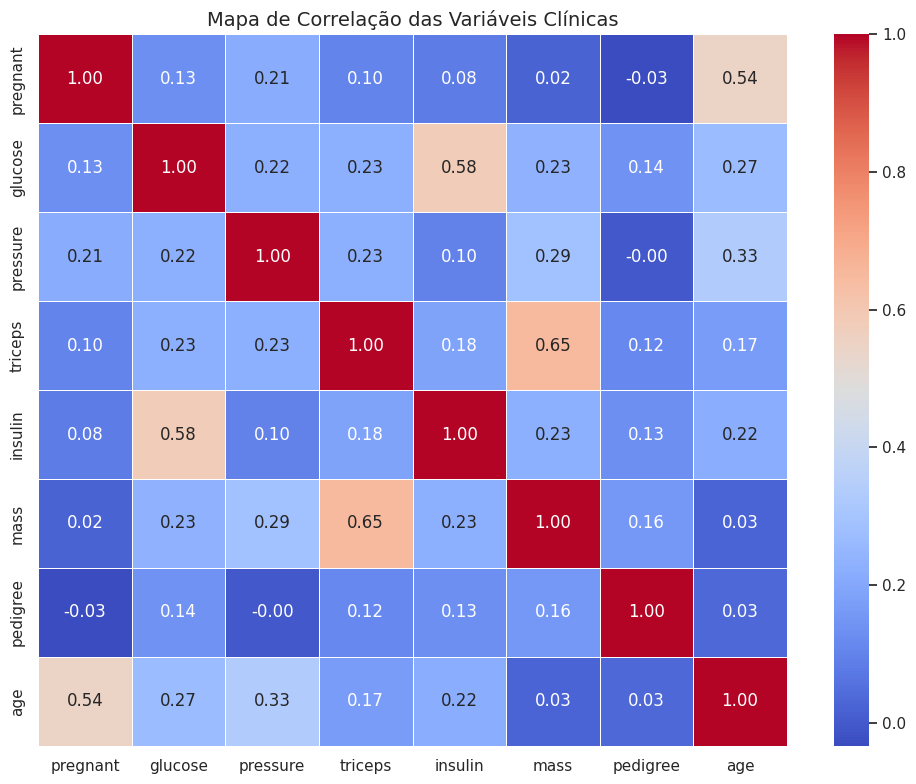

In [ ]:
plt.figure(figsize=(10, 8))

corr = df.drop('diabetes', axis=1).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Correlação das Variáveis Clínicas', fontsize=14)
plt.tight_layout()
plt.show()

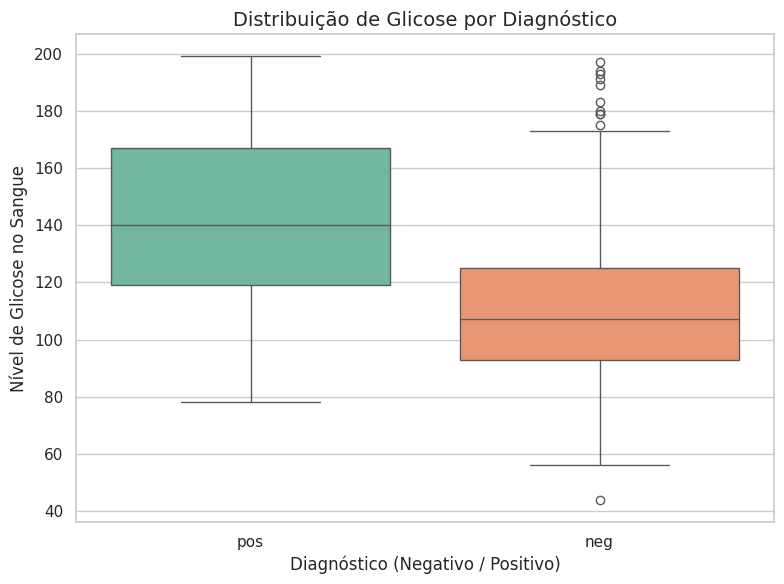

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='diabetes', y='glucose', data=df, palette='Set2', hue='diabetes', legend=False)
plt.title('Distribuição de Glicose por Diagnóstico', fontsize=14)
plt.xlabel('Diagnóstico (Negativo / Positivo)', fontsize=12)
plt.ylabel('Nível de Glicose no Sangue', fontsize=12)
plt.tight_layout()
plt.show()

Boxplot da Glicose: A linha no meio da caixa é a Mediana (o valor exatamente no meio). As linhas verticais (bigodes) mostram a dispersão normal, e os pontos soltos fora das linhas são os outliers (valores atípicos/extremos).

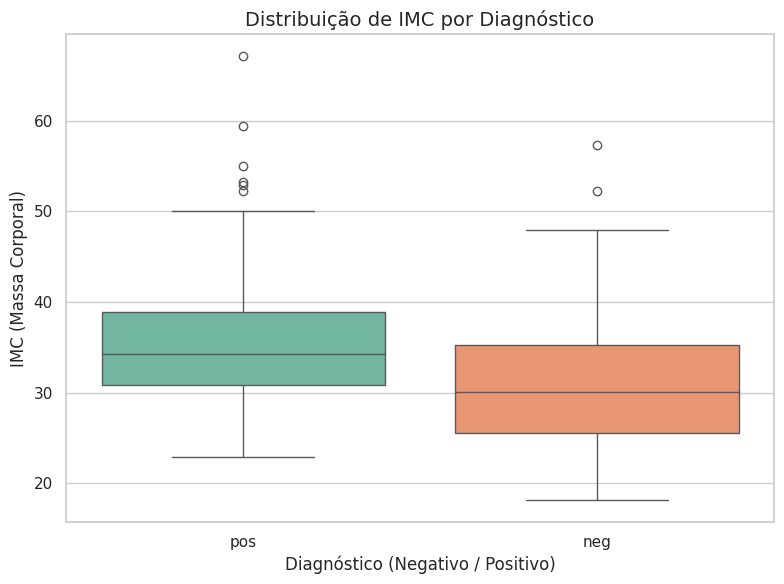

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='diabetes', y='mass', data=df, palette='Set2', hue='diabetes', legend=False)
plt.title('Distribuição de IMC por Diagnóstico', fontsize=14)
plt.xlabel('Diagnóstico (Negativo / Positivo)', fontsize=12)
plt.ylabel('IMC (Massa Corporal)', fontsize=12)
plt.tight_layout()
plt.show()

Boxplot do Índice de Massa Corporal: Segue exatamente a mesma mecânica do Boxplot anterior (caixa, mediana, quartis e outliers), mas agora aplicado à coluna de Massa Corporal (mass).

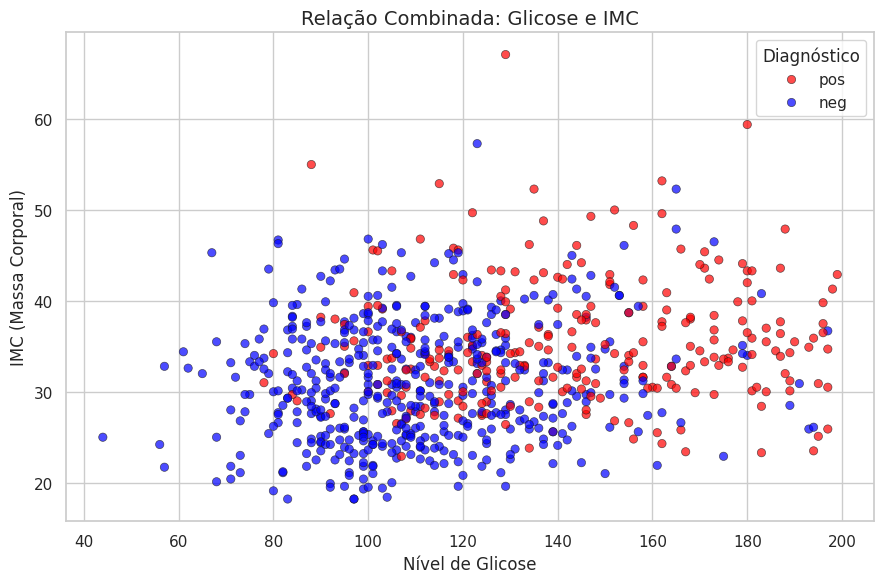

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(x='glucose', y='mass', hue='diabetes', data=df,
                palette={'pos': 'red', 'neg': 'blue'}, alpha=0.7, edgecolor='k')

plt.title('Relação Combinada: Glicose e IMC', fontsize=14)
plt.xlabel('Nível de Glicose', fontsize=12)
plt.ylabel('IMC (Massa Corporal)', fontsize=12)
plt.legend(title='Diagnóstico')
plt.tight_layout()
plt.show()

Gráfico de Dispersão Glicose x IMC: O Scatter Plot cruza duas variáveis contínuas numéricas (Glicose no eixo X e IMC no eixo Y). Cada ponto no gráfico representa uma mulher (uma paciente do dataset). Colorimos os pontos de forma diferente dependendo se ela tem diabetes (vermelho) ou não (azul).

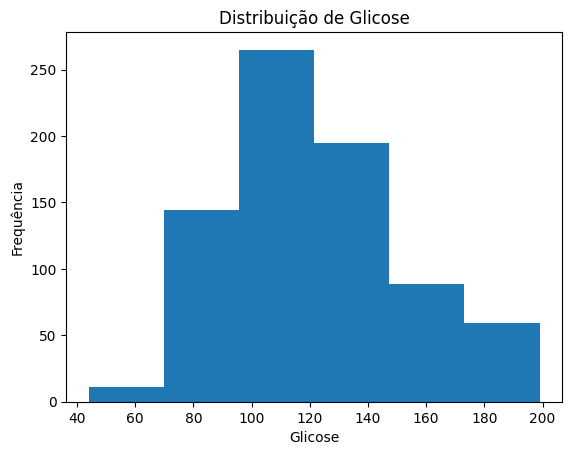

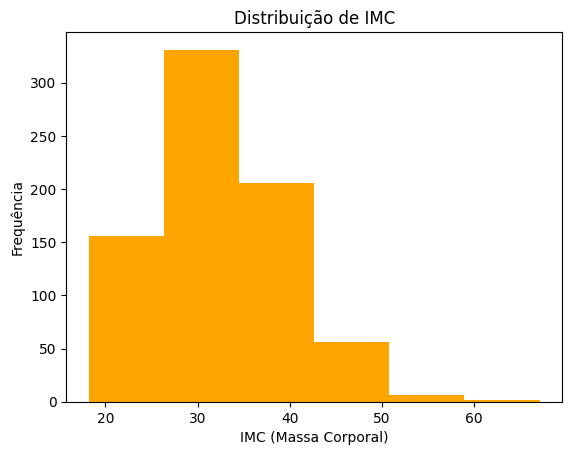

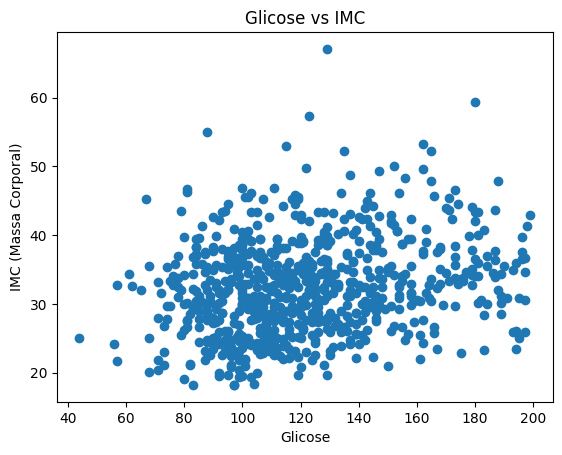

          glucose      mass
glucose  1.000000  0.232771
mass     0.232771  1.000000


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base = pd.read_csv('PimaIndiansDiabetes.csv')
cols_with_zeros = ['glucose', 'pressure', 'triceps', 'insulin', 'mass']
base[cols_with_zeros] = base[cols_with_zeros].replace(0, np.nan)


plt.hist(base['glucose'].dropna(), bins=6)
plt.title('Distribuição de Glicose')
plt.ylabel('Frequência')
plt.xlabel('Glicose')
plt.show()


plt.hist(base['mass'].dropna(), bins=6, color='orange')
plt.title('Distribuição de IMC')
plt.ylabel('Frequência')
plt.xlabel('IMC (Massa Corporal)')
plt.show()


plt.scatter(base['glucose'], base['mass'])
plt.title('Glicose vs IMC')
plt.xlabel('Glicose')
plt.ylabel('IMC (Massa Corporal)')
plt.show()

correlacao = base[['glucose', 'mass']].corr()
print(correlacao)

O Histograma Azul,divide as pacientes em 6 "faixas" de Glicose. A maior parte das pacientes concentra-se no meio, por volta dos 100 a 125 mg/dL.

O Histograma Laranjafaz o mesmo para o IMC. Mostra uma concentração altíssima de mulheres indígenas com IMC na faixa dos 30 a 40.

O Scatter Plot plota as duas variáveis em conjunto. Embora seja parecido com o que fizemos no "Gráfico 4" anteriormente, ele está na versão mais crua (sem diferenciar por cores o diagnóstico do diabetes).

A Correlação: A matriz de correlação apontou um valor de 0.23. Isso indica que existe uma relação positiva, porém fraca, entre a glicose subir de forma linear com o IMC quando não separamos as pacientes doentes das saudáveis.